# Quality Assurance

<a target="_blank" href="https://colab.research.google.com/github/zentralbibliothek-zuerich/zblab-summerschool-2026/blob/main/notebooks/02_quality_assurance.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a> 

This notebook contains boilerplate code that you don't need to interact with directly.

The sections where you can safely experiment or customize are clearly marked with such comments:

```python
# ⬇️⬇️⬇️
YOUR_INPUT = ""
# ⬆️⬆️⬆️
```

## Setup

### Housekeeping (no interaction required)
You only need to execute the cells (press <img src="https://api.iconify.design/icon-park-solid/play.svg" alt="▶️" width=12> to the left of the cells).

In [42]:
%pip install "impresso_pipelines[ocrqa]"

/home/bode-wsl/projects/summerschool26/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


❗ Please restart the kernel/runtime after installing the package to ensure that all changes take effect.

(Google Colab might initiate a restart on its own)

In [43]:
import os
from pathlib import Path
import textwrap
from typing import Literal

import pandas as pd
from tqdm.notebook import tqdm

In [44]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBLabSummerSchool2026/data') if IN_COLAB else Path('../data')

### Setup (interaction required)

In [45]:
### ⬇️⬇️⬇️  Adjust here if you want to load the data from your google drive
CORPUS_NAME = "armenpflege"
USE_YOUR_DATA = False
### ⬆️⬆️⬆️

## Load the data

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

<img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=12> The cell below will attempt to connect to your Google Drive.

*Once prompted, give all demanded permissions*

In [46]:
if IN_COLAB and USE_YOUR_DATA: #confirm("Do you want to mount your Google Drive?"):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

In [47]:
if USE_YOUR_DATA:
    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.full.parquet" 
    raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from example

In [48]:
if not USE_YOUR_DATA:
    RAWDATA_URL = f"https://media.githubusercontent.com/media/zentralbibliothek-zuerich/zblab-summerschool-2026/main/data/armenpflege.full.parquet"
    raw_df = pd.read_parquet(RAWDATA_URL)

### Parsing and preparing

For easier handling, the cell below extracts only the year from the complex date column.

`1880-03-07T00:00:00+00:00` ➡️ `1880`


In [49]:
raw_df["year"] = pd.to_datetime(raw_df["date"]).dt.year

## OCR quality assessment

In [50]:
from impresso_pipelines.ocrqa import OCRQAPipeline

In [51]:
ocrqa_pipeline = OCRQAPipeline()

In [52]:
# ⬇️⬇️⬇️ Adjust here if your data is in another language
LANGUAGE = "de"
# ⬆️⬆️⬆️

def assess_quality(s: str,) -> float:
    """Estimate OCR quality for one article text.

    Args:
        s: Raw article text.

    Returns:
        OCR quality score between 0 and 1.
    """
    qa = ocrqa_pipeline(s, language=LANGUAGE)
    return qa["score"]

tqdm.pandas(desc="Assessing OCR quality")
raw_df["ocr_quality"] = raw_df["content"].progress_apply(assess_quality)

Assessing OCR quality:   0%|          | 0/6972 [00:00<?, ?it/s]

## Inspect the quality

### OCR quality distribution over time

In [53]:
import numpy as np

# Define number of tiers
N = 10
bins = np.linspace(0, 1, N + 1)
tier_labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(N)]

raw_df["quality_tier"] = pd.cut(
    raw_df["ocr_quality"],
    bins=bins.tolist(),
    labels=tier_labels,
    include_lowest=True
)

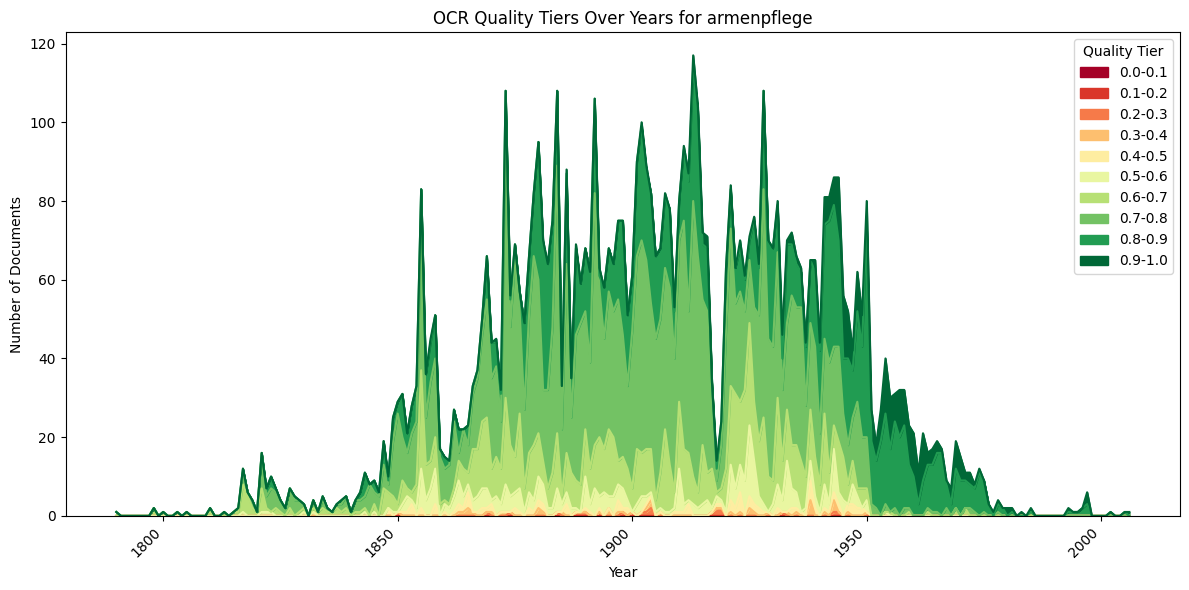

In [54]:
import matplotlib.pyplot as plt

def plot_quality_tiers_over_time(df: pd.DataFrame) -> None:
    """Plot OCR quality tiers across years.

    Args:
        df: Dataframe with year and OCR quality columns.
    """
    df = df.copy()

    # Group by year and quality tier, then count occurrences
    df_grouped = df.groupby(['year', 'quality_tier'], observed=False).size().unstack(fill_value=0)
    full_index = range(df_grouped.index.min(), df_grouped.index.max() + 1)
    df_grouped = df_grouped.reindex(full_index, fill_value=0)

    cmap = plt.cm.RdYlGn
    colors = {label: cmap(i / (N - 1)) for i, label in enumerate(tier_labels)}

    # Plot the stacked bar chart
    ax = df_grouped.plot(kind='area', stacked=True, figsize=(12, 6),
                            color=[colors[col] for col in df_grouped.columns]
    )

    # Add title and labels
    plt.title(f'OCR Quality Tiers Over Years for {CORPUS_NAME}')
    plt.xlabel('Year')
    plt.ylabel('Number of Documents')
    plt.legend(title='Quality Tier')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_quality_tiers_over_time(raw_df)

### Inspect examples of quality tiers

In [55]:
unique_quality_tiers = raw_df['quality_tier'].unique()

for tier in sorted(unique_quality_tiers):
    # Filter the DataFrame for the current tier
    tier_df = raw_df[raw_df['quality_tier'] == tier]

    # Select a random example from the filtered DataFrame
    if not tier_df.empty:
        example = tier_df.sample(1).iloc[0]
        print(f"OCR Quality Score: {example['ocr_quality']:.2f}")
        print(textwrap.fill(example['content'][:500], width=80)) # Wrap content for display
        print()

OCR Quality Score: 0.26
fUtptnoliftifätz Wittmt 3 ur Sabafmonopolbotfdjaft bti SBunbeS « wies äufjcrt
fidj in bclucrfcnöwcrtcr Seife ber .; i, » Biiiioc « j | tabtrorrcfpßitbeut beS
„» aterlanb 1 | G. SBärj). Qm folgcnben loill idj jtoei Stellen WWIlS
glofficrcn, oljne in eine Slritif bc: Gtnirblagc einzutreten, fonbern biefe alö
j oiiijc iinf a « lj übe r uc tjmcub. Der Stetifcl führt alte, bau für eine
Sirieg *: « Ktiite bou runb 700 Millionen ber ( itegeuwM gefuttert fei, unb
fiiljlt bann fort: „ Die Stricgöjdjulb m

OCR Quality Score: 0.36
Montag, 12. April lM3 Vlatt Neue Zürcher Zeitung Morgenausgabe Vr. 595 Die
Luftoffensive der Alliierten im Westen Vombardieruna. von Duisburg Im
Hauptquartier «. l., IN. April. syr, l, ange) Äiit mehreren Stassrlu schwerer
Bomber wurde in der Nacht zum Tamstaq Duisburg, der ssröhtc Inlandliasen Europa
'?, von der k. / V. I '. angegriffen, fünfzehn? 1cinii >; ten wurden viele
Tonnen schwerster (frplosiv » bomben und cinisse liunderttausend aus Dui

Use `diagnostics=True` in the  to see how the QA-pipeline arrives at the score.

In [56]:
# ⬇️⬇️⬇️ Insert a text to see how it arrives at the OCR quality score
TEXT = """
»,',,>; ^ ''', 'V. s'^ reich zum Vorschießen erschienenen ge >; PublilumZ
lunden. Die Schützen » ucrden ani nächste,! Tanztag Eouutag und mit drei
verschiedenen Armbrustsystenien in den Uampf Wichen: die O rd die u n n a n, z »
Wasfe i verbreitetste imd steht der P ri a t ^ >; nsseiw, u, ge° Wafse m ? auch
ge?,» mt? wenig nnch, >; väl, rcud Heri-ZuueiNKisse die sug. NiandU'affe,
übrigen leltenei vertreten, zwei Punltznschlage uergiitet be Gesundere, i >; n
"""
LANG = "de"
# ⬆️⬆️⬆️

def assess_quality_with_diagnostics(s: str) -> None:
    """Estimate OCR quality for one article text with diagnostics.

    Args:
        s: Raw article text.
    Returns:
        OCR quality score between 0 and 1, along with diagnostics.
    """

    obj = ocrqa_pipeline(s, language=LANG, diagnostics=True)

    indent = 4 * " "
    print("Text:")
    print(textwrap.fill(text=s, width=80, initial_indent=indent, subsequent_indent=indent), end="\n\n")
    print("Score:")
    print(indent, f"{obj['score']:.2f}", end="\n\n")
    print("Unknown Tokens:")
    unk = textwrap.fill(" ".join(obj['diagnostics']['unknown_tokens']), width=80, initial_indent=indent, subsequent_indent=indent) 
    print(unk)

assess_quality_with_diagnostics(TEXT)

Text:
     »,',,>; ^ ''', 'V. s'^ reich zum Vorschießen erschienenen ge >; PublilumZ
    lunden. Die Schützen » ucrden ani nächste,! Tanztag Eouutag und mit drei
    verschiedenen Armbrustsystenien in den Uampf Wichen: die O rd die u n n a n,
    z » Wasfe i verbreitetste imd steht der P ri a t ^ >; nsseiw, u, ge° Wafse m
    ? auch ge?,» mt? wenig nnch, >; väl, rcud Heri-ZuueiNKisse die sug.
    NiandU'affe, übrigen leltenei vertreten, zwei Punltznschlage uergiitet be
    Gesundere, i >; n

Score:
     0.58

Unknown Tokens:
    ''' ,, > ^ armbrustsystenien eouutag ge gesundere heri-zuueinkisse imd
    leltenei n niandu'affe nnch nsseiw publilumz punltznschlage rcud s sug t
    tanztag uampf ucrden uergiitet vorschießen väl wafse wasfe z »


In [57]:
def plot_documents_per_year_intervals(
    df: pd.DataFrame,
    n_years: int,
    group: Literal["media_title", "country_code", "province_code"] | None = None,
) -> None:
    """Plot document counts per time interval, optionally grouped.

    Args:
        df: Input dataframe that includes a year column.
        n_years: Width of each year bucket.
        group: Optional metadata field used for stacked grouping.
    """
    df = df.copy()
    start = (df["year"].min() // n_years) * n_years
    end = (df["year"].max() // n_years + 1) * n_years

    # Include the final bin edge so the newest interval is not dropped.
    bins = range(start, end + 1, n_years)
    labels = [f"{b}-{b+n_years-1}" for b in bins[:-1]]
    df["year_interval"] = pd.cut(df["year"], bins=bins, labels=labels, include_lowest=True)

    fig, ax = plt.subplots(figsize=(12, 6))

    if group is None:
        # Un-grouped view.
        df.groupby("year_interval", observed=False).size().plot(kind="bar", ax=ax)
        ax.set_title(f"Number of Documents per {n_years}-Year Interval")
    else:
        # Grouped view: keep top 5 categories and collapse the rest into "Other".
        top_groups = df[group].value_counts().nlargest(5).index
        df[group] = df[group].where(df[group].isin(top_groups), other="Other")
        (
            df.groupby(["year_interval", group], observed=False)
            .size()
            .unstack(fill_value=0)
            .plot(kind="bar", stacked=True, ax=ax)
        )
        ax.set_title(f"Number of Documents per {n_years}-Year Interval and {group}")
        ax.legend(title=group)

    ax.set_xlabel("Year Interval")
    ax.set_ylabel("Number of Documents")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    fig.tight_layout()
    plt.show()

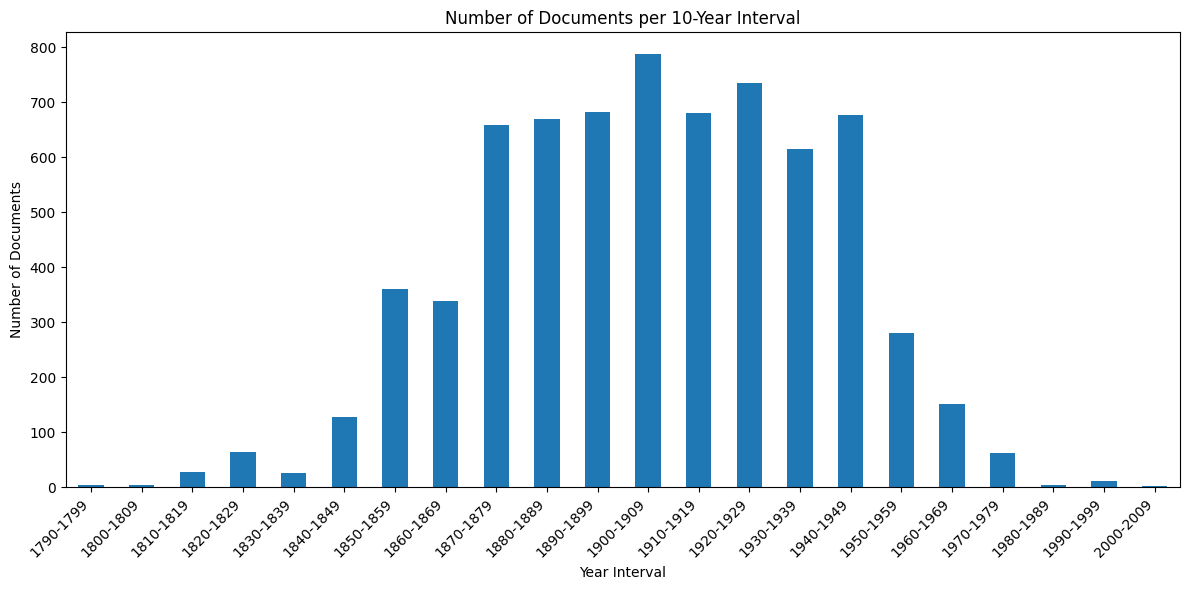

In [58]:
# ⬇️⬇️⬇️ Change the n_years to see how different bucketing affects possible conclusions
plot_documents_per_year_intervals(raw_df, n_years=10)
# ⬆️⬆️⬆️

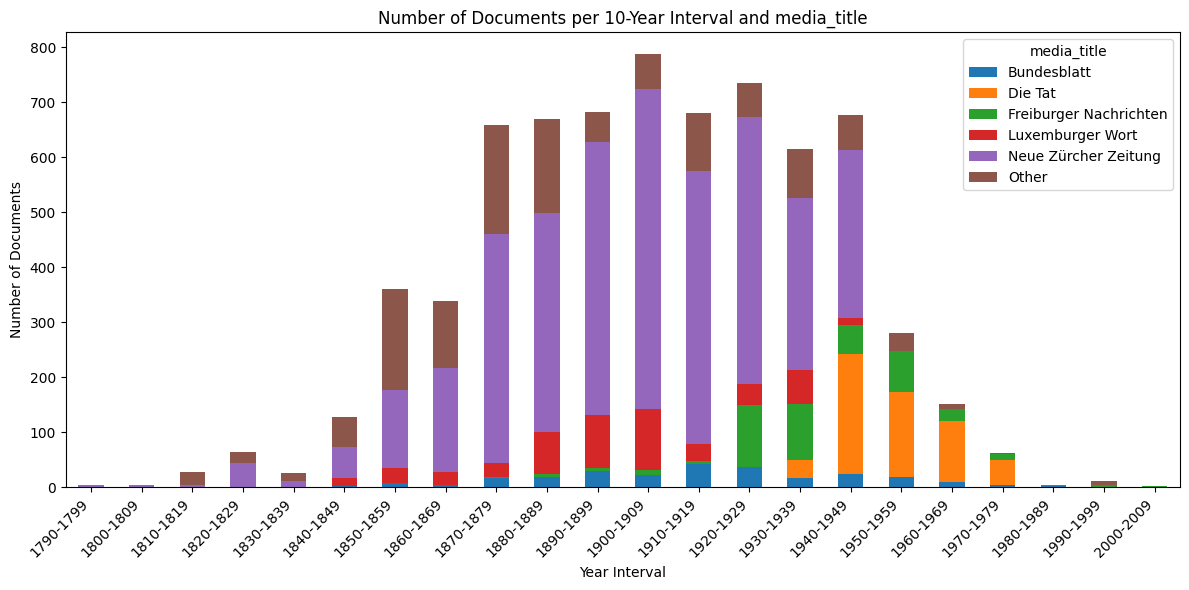

In [59]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(raw_df, n_years=10, group="media_title")
# ⬆️⬆️⬆️

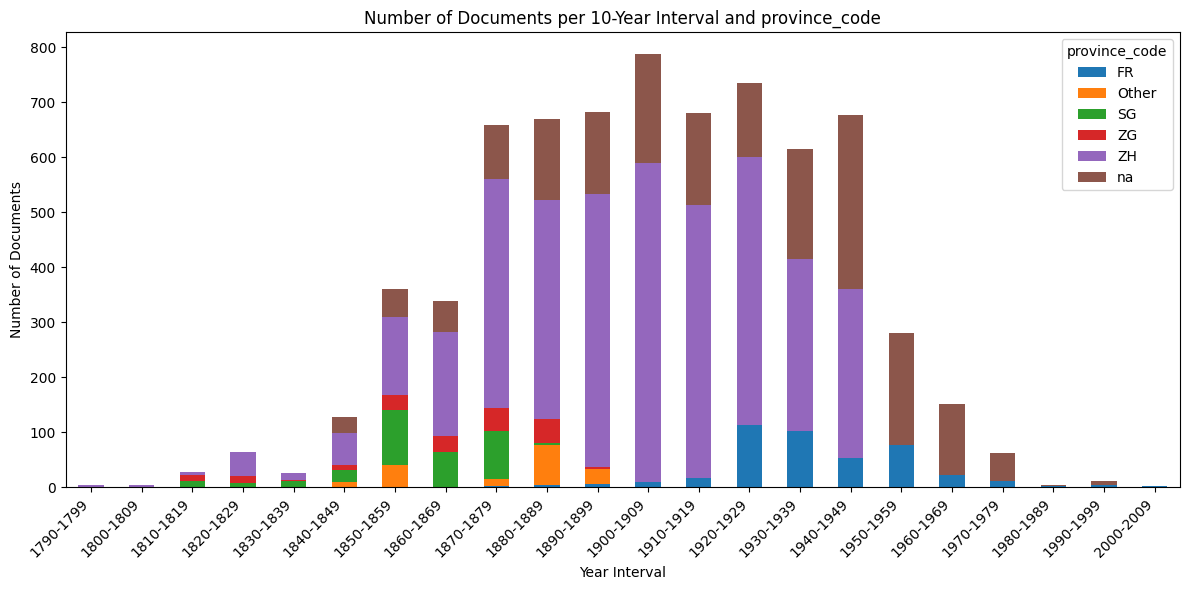

In [60]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(raw_df, n_years=10, group="province_code")
# ⬆️⬆️⬆️

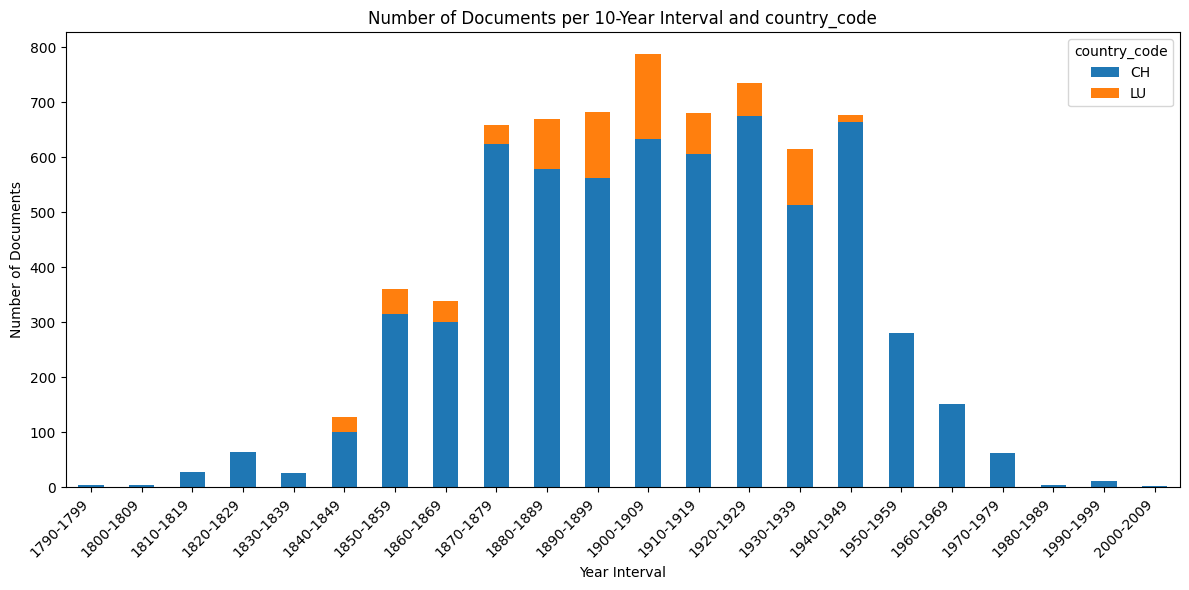

In [61]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(raw_df, n_years=10, group="country_code")
# ⬆️⬆️⬆️

## Filter corpus

### Apply filter

In [62]:
# ⬇️⬇️⬇️
QUALITY_CUTOFF = 0.8
# ⬆️⬆️⬆️

df_filtered = raw_df[raw_df["ocr_quality"] >= QUALITY_CUTOFF]

print(f"Number of documents after filtering: {len(df_filtered)} out of {len(raw_df)}")

Number of documents after filtering: 2633 out of 6972


### Inspect remaining data

Check how much of the full corpus remains.
Is it enough for your research questions?

You might need to find a compromise between your ideals and the potential for certain analyses. 

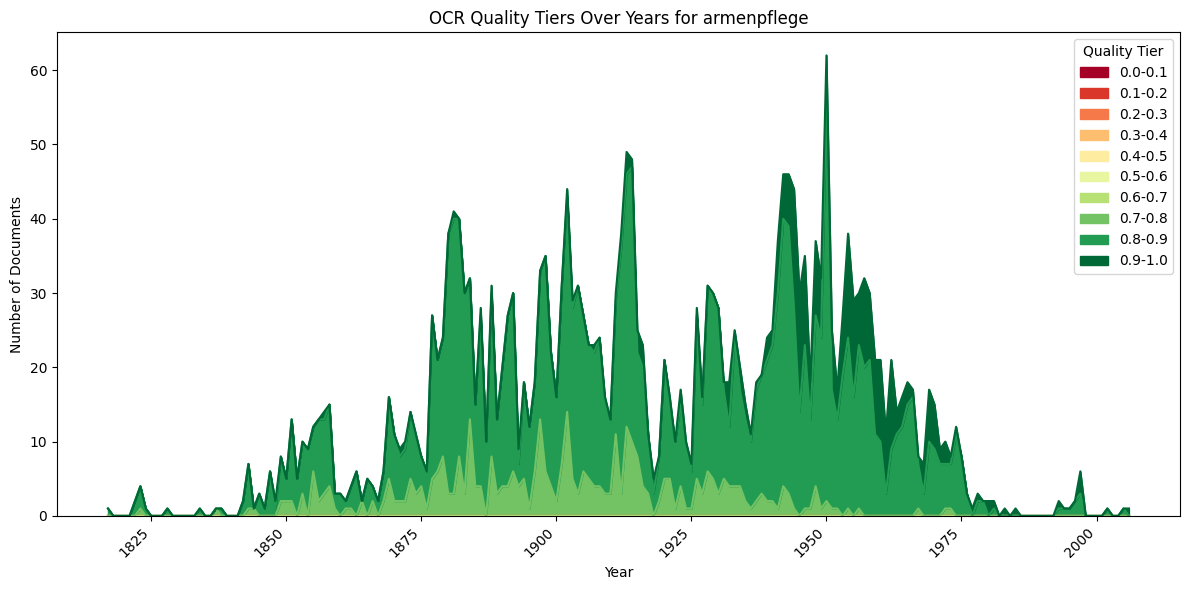

In [63]:
plot_quality_tiers_over_time(df_filtered)

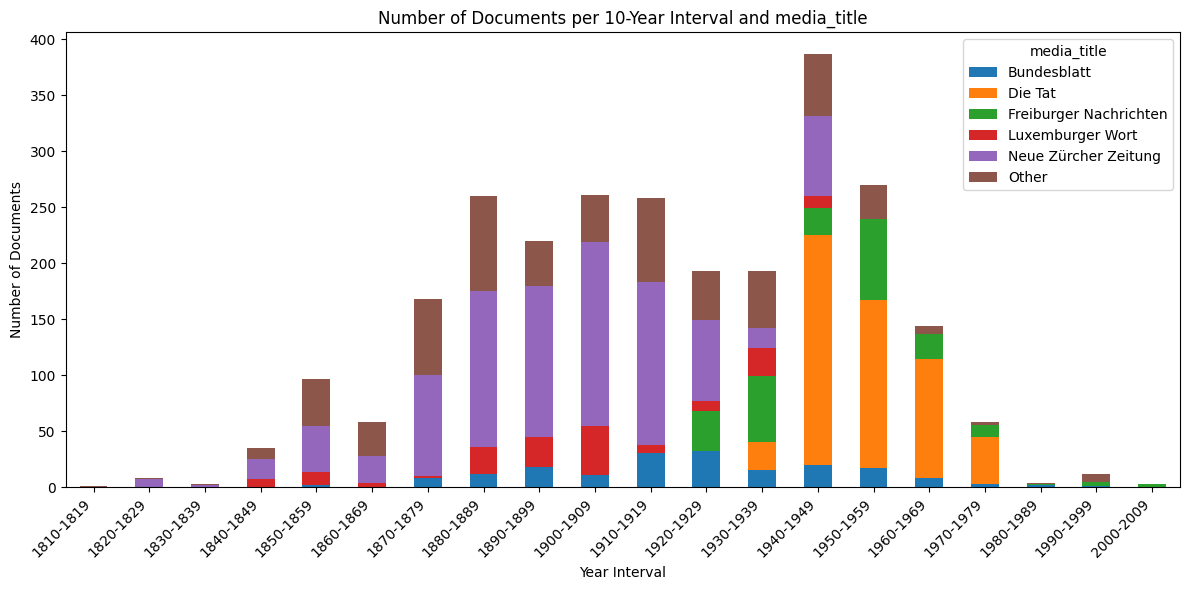

In [64]:
# ⬇️⬇️⬇️
plot_documents_per_year_intervals(df_filtered, n_years=10, group="media_title")
# plot_documents_per_year_intervals(df_filtered, n_years=10, group="media_title")
# plot_documents_per_year_intervals(df_filtered, n_years=10, group="province_code")
# plot_documents_per_year_intervals(df_filtered, n_years=10, group="country_code")
# ⬆️⬆️⬆️

### Save the filtered corpus

In [65]:
if USE_YOUR_DATA:
    df_filtered = df_filtered.drop(columns=["quality_tier", "year"])
    df_filtered.to_parquet(DATA_DIR / f"{CORPUS_NAME}.filtered.parquet")
    print(f"Filtered data saved to {DATA_DIR / f'{CORPUS_NAME}.filtered.parquet'}")
    print(f"Lowest quality score in filtered data: {df_filtered['ocr_quality'].min():.2f}")